# Higher-order rules: what the longer rules add

## Configuration & Constants
Everything to tune lives here.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import os
import sys
import ast
import warnings
warnings.filterwarnings('ignore')

# Add root to path for utils
sys.path.append(os.path.abspath('../..'))   # project root
sys.path.append(os.path.abspath('..'))          # shared helpers, one level up

# Shared loader + rule-name cleaning (also used by the other result-summary notebooks)
import data_helper as dh
from data_helper import base_items, clean_items, check_rule_overlap

# Plotting helpers live next to this notebook
import complex_vis as cv
from IPython.display import Markdown

In [2]:
# ==========================================
# CONFIGURATION & CONSTANTS
# ==========================================
# Which run: data_helper.RESULT_CSV_PATH, shared by every notebook. Its rules must be
# split into the pairwise / complex files first - run prepare_data.ipynb once per run.

# Which rules take part
RULE_MAX_ITEMS = 4     # up to four items, so the longer rules come in too
KIND    = 'attracts'   # 'attracts', 'avoids', or None for both
NO_SELF = True         # drop rules where a cell type repeats (Paneth + Paneth -> Goblet)
MAX_FDR = 0.05         # the per-FOV significance bar, applied per plot and not at load

# How FOVs are grouped
SCORE_COLUMN = 'Pathological score'
STAGE_ORDER  = ['Control', 'Mild', 'Severe']
ORGAN_ORDER  = ['Colon', 'Duodenum']

# The three shapes a longer rule can take, in the order the plots draw them.
SHAPE_ORDER  = ['ant-complex', 'con-complex', 'both-complex']
SHAPE_LABELS = {'pairwise':     'A -> B',
                'ant-complex':  'A + B -> C',
                'con-complex':  'A -> B + C',
                'both-complex': 'A + B -> C + D'}

# The library's verdicts, worst first: the two that add nothing, then the four that do.
CLASS_ORDER  = ['redundant_by_simpler', 'consequent_driven',
                'simpler_are_noise', 'consequent_is_noise', 'stronger_effect', 'new']
CLASS_LABELS = {'redundant_by_simpler': 'a shorter rule said it',
                'consequent_driven':    'consequents do it alone',
                'simpler_are_noise':    'shorter rules too weak',
                'consequent_is_noise':  'backing pair too weak',
                'stronger_effect':      'clearly stronger',
                'new':                  'nothing shorter mined'}

# Left-to-right order for each column a plot can be split by.
GROUP_ORDER = {SCORE_COLUMN: STAGE_ORDER, 'Clinical score': STAGE_ORDER,
               'Organ': ORGAN_ORDER, 'Kind': ['attracts', 'avoids']}

# Plot B measures the gain in one metric. Only these three have a defined 'chance'
# point (1, 1, 0), which is what lets an avoidance rule be read the same way round.
METRIC     = 'Lift'
MIN_GAIN   = 1.1     # the library's own bar: how much a longer rule must beat a shorter one by
MIN_FOVS   = 5       # a rule has to fire in this many FOVs before it is ranked or named
TOP_N      = 15

# Where a rule that was never mined must have sat: the bar it failed, on the strength
# scale, which is the most it could have been. See the run's run_config.json.
MINING_BAR = {('attracts', 'Lift'): 1.2, ('avoids', 'Lift'): 1.25,
              ('attracts', 'Conviction'): 1.3}

## Load Data
Reads whichever run `data_helper.RESULT_CSV_PATH` names, so run `prepare_data.ipynb`
once on a new run to split its rules into the pairwise and complex files.

In [3]:
# Load cells, FOVs and biopsies (shared loader, see data_helper.py).
df_cells, df_fovs, df_biopsy = dh.load_spatial_data()

Dropped 21 FOVs: Control_S
Loaded 598093 cells; FOVs: 267, biopsies: 73, patients: 71


In [4]:
# Load the mined rules (shared loader, see data_helper.py).
# max_fdr=1 keeps every rule: each plot sets its own bar, and a longer rule's simpler
# parts have to still be in the table to be looked up. informative_only=False keeps
# the redundant rules, which are half of what this notebook shows.
df_results = dh.load_results(rule_max_items=RULE_MAX_ITEMS, kind=KIND, max_fdr=1.0,
                             informative_only=False)

Read results_CN_pairwise.csv + results_CN_complex.csv
Loaded 1190114 rules.
Kept 1190114 rules at FDR <= 1.0.
Kept 727458 rules (max_items=4, kind=attracts).


In [5]:
def drop_self_rules(rules, no_self=NO_SELF):
    """Drop rules where a cell type repeats (Paneth + Paneth -> Goblet)."""
    if not no_self:
        return rules
    repeats = [check_rule_overlap(base_items(a), base_items(c))
               for a, c in zip(rules['Antecedents'], rules['Consequents'])]
    return rules[~pd.Series(repeats, index=rules.index)]


def attach_metadata(rules, df_fovs):
    """Add Organ, Biopsy and PatientID to every rule row.

    Only the FOVs load_spatial_data kept take part - filtered first, then merged, the
    same order pair_analysis uses, so the merge itself can never drop a row.
    """
    kept = rules[rules['FOV'].isin(df_fovs['FOV'])]
    if len(kept) < len(rules):
        print(f"Dropped {len(rules) - len(kept):,} rule rows, from "
              f"{rules['FOV'].nunique() - kept['FOV'].nunique()} FOVs left out above.")

    merged = kept.merge(df_fovs[['FOV', 'Organ', 'Biopsy', 'PatientID']],
                        on='FOV', how='left')
    print(f"{len(merged):,} rule rows over {merged['FOV'].nunique()} FOVs, "
          f"{merged['Biopsy'].nunique()} biopsies, {merged['PatientID'].nunique()} patients.")
    return merged


df_results = attach_metadata(df_results, df_fovs)

Dropped 59,440 rule rows, from 21 FOVs left out above.
668,018 rule rows over 267 FOVs, 73 biopsies, 71 patients.


In [6]:
def rule_counts(rules, max_fdr=MAX_FDR, no_self=NO_SELF):
    """How many rules of each shape came in, and how many clear the FDR bar."""
    rules = drop_self_rules(rules, no_self)
    shape = rules['Rule_Type'].map(SHAPE_LABELS)
    return pd.DataFrame({
        'rules':       shape.value_counts(),
        'significant': shape[rules['Individual_FDR'] <= max_fdr].value_counts(),
    }).reindex([SHAPE_LABELS[s] for s in ['pairwise'] + SHAPE_ORDER])

display(rule_counts(df_results))

,rules,significant
Rule_Type,,
A -> B,4978,2756
A + B -> C,260171,107795
A -> B + C,18809,7851
A + B -> C + D,106720,40283


## Plot A - how the verdicts split
Of the rules longer than pairwise, how many say something new and how many
just repeat a shorter rule?

In [7]:
def class_split(rules, split_by=None, max_fdr=None, no_self=NO_SELF):
    """How the verdicts split: one row per rule shape, per group if split_by is given.

    split_by : a column to break the rows down by - 'Pathological score', 'Organ', 'Kind'.
    max_fdr  : keep only rules this significant; None counts every mined rule.
    no_self  : drop the rules where a cell type repeats.
    """
    part = drop_self_rules(rules, no_self)
    part = part[part['Rule_Type'].isin(SHAPE_ORDER)]
    if max_fdr is not None:
        part = part[part['Individual_FDR'] <= max_fdr]

    keys = ([split_by] if split_by else []) + ['Rule_Type']
    counts = (part.groupby(keys + ['Complex_Class']).size()
              .unstack('Complex_Class', fill_value=0))
    counts = counts[[c for c in CLASS_ORDER if c in counts.columns]]

    wanted = row_order(part, split_by)
    return counts.reindex([row for row in wanted if row in counts.index])


def row_order(part, split_by):
    """The rows in reading order: the shapes, inside each group."""
    if not split_by:
        return SHAPE_ORDER

    present = list(part[split_by].dropna().unique())
    groups = [g for g in GROUP_ORDER.get(split_by, []) if g in present]
    groups += [g for g in present if g not in groups]
    return [(group, shape) for group in groups for shape in SHAPE_ORDER]

In [8]:
def show_class_split(split_by=None, max_fdr=None, save=None):
    """Draw Plot A on any slice. Change what you pass in; nothing else needs touching."""
    bar = f"FDR <= {max_fdr}" if max_fdr else "every mined rule"
    cv.plot_class_split(class_split(df_results, split_by, max_fdr),
                        labels=SHAPE_LABELS, class_labels=CLASS_LABELS,
                        scope=f"{KIND}, {bar}", save=save)

In [9]:
display(class_split(df_results))

Complex_Class,redundant_by_simpler,consequent_driven,simpler_are_noise,consequent_is_noise,stronger_effect,new
Rule_Type,,,,,,
ant-complex,129063,0,85440,0,17340,28328
con-complex,7221,363,6821,203,2904,1297
both-complex,42624,2001,36053,1124,20997,3921


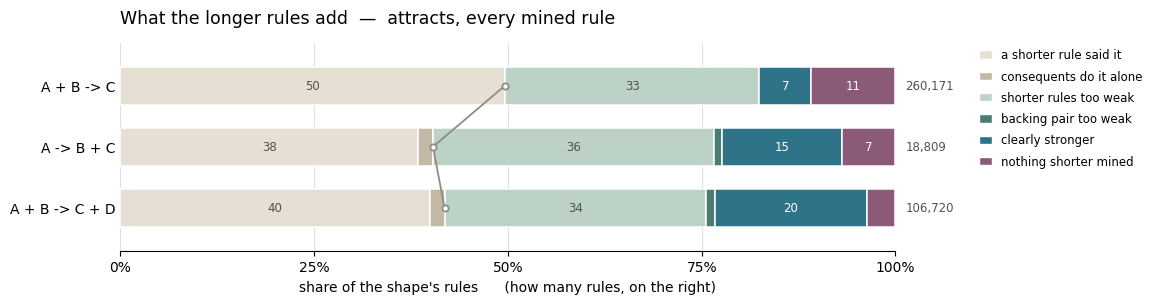

In [10]:
show_class_split()

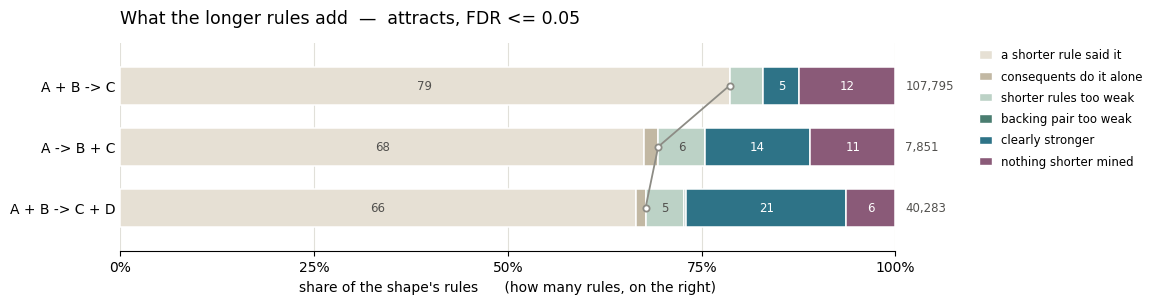

In [11]:
# Only the rules that clear the per-FOV significance bar.
show_class_split(max_fdr=MAX_FDR)

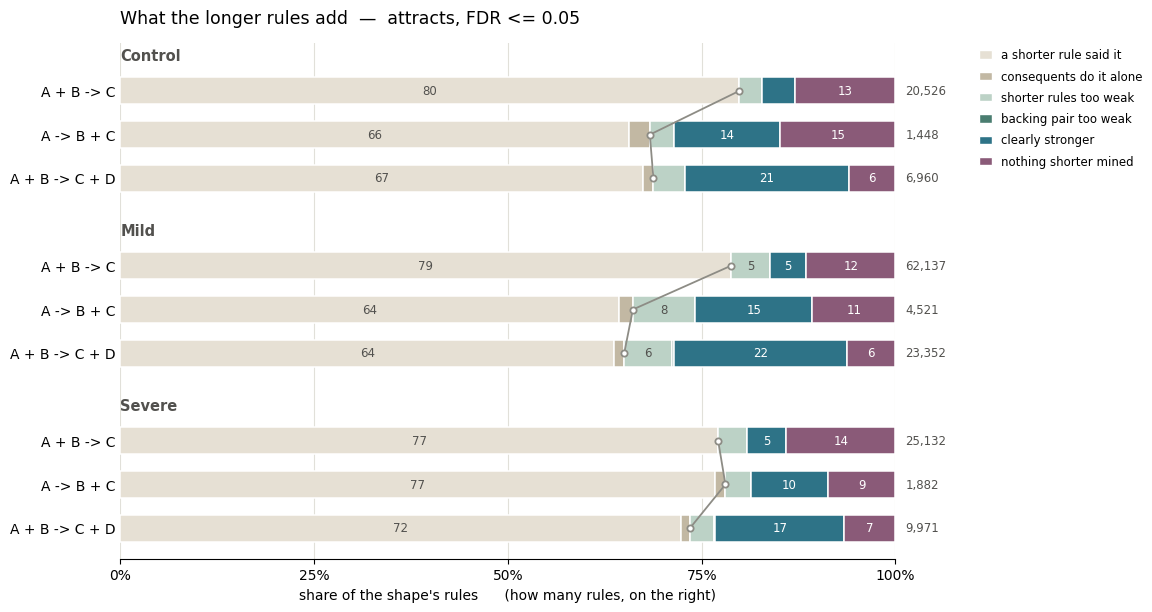

In [12]:
# One block per disease stage.
show_class_split(split_by=SCORE_COLUMN, max_fdr=MAX_FDR)

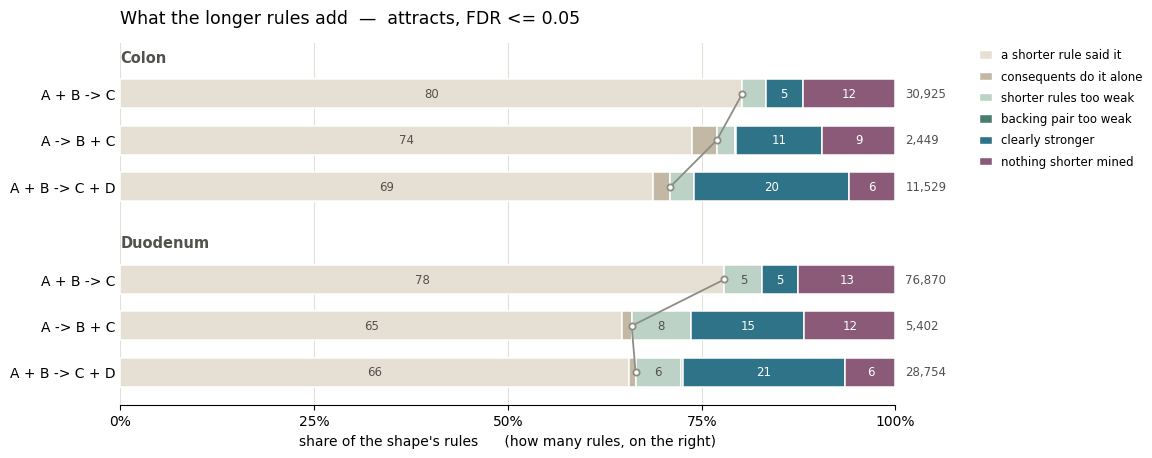

In [13]:
# One block per organ.
show_class_split(split_by='Organ', max_fdr=MAX_FDR)

## Plot B - how much the longer rules gain
Of the longer rules that survived, how much stronger are they than the best shorter rule
inside them?

In [14]:
def strength(rules, metric=METRIC):
    """How far from chance, so bigger always means stronger - both kinds on one scale.

    Avoidance is strong when the metric goes down, so it is turned over: lift 0.25 and
    lift 4 are equally far from chance, one avoiding and one attracting.
    """
    value = rules[metric].astype(float)
    if metric == 'Leverage':
        return value.abs()
    return value.where(rules['Kind'] == 'attracts', 1.0 / value.clip(lower=1e-6))


def rule_key(rules):
    """The name the library writes in Simpler_Rules: items sorted, roles kept."""
    ant = rules['Antecedents'].map(lambda s: ' + '.join(sorted(ast.literal_eval(s))))
    con = rules['Consequents'].map(lambda s: ' + '.join(sorted(ast.literal_eval(s))))
    return ant + ' -> ' + con


def plain_name(name):
    """A Simpler_Rules name with its role tags dropped, so it reads like a rule name."""
    if not isinstance(name, str):
        return 'nothing shorter was mined'
    sides = [', '.join(sorted(item.replace('_CENTER', '').replace('_NEIGHBOR', '')
                              for item in side.split(' + ')))
             for side in name.split(' -> ')]
    return ' -> '.join(sides)


def best_parent(rules, metric=METRIC):
    """The strongest shorter rule inside each rule, measured in the same FOV.

    Simpler_Rules names what the library weighed each rule against; every one of those
    is looked up in the same FOV, and the strongest wins. Read off the whole table, not
    a filtered one: a parent dropped for being insignificant would look like a parent
    that was never mined.

    Returns its strength and its name.
    """
    found = dict(zip(zip(rules['FOV'], rules['Kind'], rule_key(rules)),
                     strength(rules, metric)))

    best, names = [], []
    for fov, kind, simpler in zip(rules['FOV'], rules['Kind'], rules['Simpler_Rules']):
        parents = [(found.get((fov, kind, name)), name)
                   for name in ast.literal_eval(simpler)]
        parents = [p for p in parents if p[0] is not None]
        value, name = max(parents) if parents else (np.nan, None)
        best.append(value)
        names.append(plain_name(name))
    return pd.DataFrame({'parent': best, 'parent_name': names}, index=rules.index)

In [15]:
def main_verdict(verdicts):
    """A rule's usual verdict. A tie goes to the more cautious one, so a rule that is
    half 'new' and half 'clearly stronger' is not filed under the assumption."""
    counts = verdicts.value_counts()
    return min(counts[counts == counts.max()].index, key=CLASS_ORDER.index)


def gain_table(rules, metric=METRIC, max_fdr=MAX_FDR, min_fovs=MIN_FOVS, per='rule',
               no_self=NO_SELF):
    """How strong each rule is, its best shorter rule, and the gain between.

    Only rules that added something and cleared the FDR bar take part, and only rules
    seen in at least min_fovs FOVs.

    per : 'fov' keeps every rule-FOV row, so nothing is averaged - use it for anything
          that draws the whole population. 'rule' collapses to one row per rule *and
          verdict*, which is what naming a rule needs.

    A rule is grouped by its verdict, not just its name, because the verdict says what
    the parent was doing: 'nothing shorter mined' FOVs have no parent, 'clearly stronger'
    FOVs have a real one. Averaging an assumed 1.2 with a measured 1.6 describes neither.
    So a rule that changes verdict between FOVs gets a row for each - which is the
    finding, not a duplicate - and the median only ever covers the FOVs behind that row.
    """
    rules = drop_self_rules(rules, no_self)
    longer = rules[rules['Rule_Type'].isin(SHAPE_ORDER)].copy()
    longer['strength'] = strength(longer, metric)
    longer[['parent', 'parent_name']] = best_parent(rules, metric).reindex(longer.index)

    # A rule with nothing shorter mined is pinned at the bar that rule must have failed:
    # the most it could have been, so the gain comes out as a floor.
    longer['parent'] = longer['parent'].fillna(MINING_BAR.get((KIND, metric), 1.0))

    kept = longer[longer['Adds_Information'] & (longer['Individual_FDR'] <= max_fdr)]
    kept = kept.assign(name=kept['Antecedents'].map(clean_items) + ' -> '
                            + kept['Consequents'].map(clean_items))
    kept['gain'] = kept['strength'] / kept['parent']

    seen = kept.groupby('name')['FOV'].nunique()
    kept = kept[kept['name'].isin(seen[seen >= min_fovs].index)]

    if per == 'fov':
        return kept.rename(columns={'Complex_Class': 'verdict'}).sort_values(
            'gain', ascending=False)

    table = kept.groupby(['name', 'Rule_Type', 'Complex_Class']).agg(
        strength=('strength', 'median'),
        parent=('parent', 'median'),
        fovs=('FOV', 'nunique'),
        parent_name=('parent_name', lambda s: s.mode().iat[0]),
    ).reset_index().rename(columns={'Complex_Class': 'verdict'})

    # The bar applies to the row, not the rule: a rule seen in 20 FOVs but 'clearly
    # stronger' in one of them must not get a row resting on a single measurement.
    table['gain'] = table['strength'] / table['parent']
    return table[table['fovs'] >= min_fovs].sort_values('gain', ascending=False)


gains = gain_table(df_results)                       # one row per rule, for naming
gain_rows = gain_table(df_results, per='fov')        # one row per rule per FOV
print(f"{len(gains)} rule+verdict rows ({gains['name'].nunique()} rules), "
      f"{len(gain_rows)} rule-FOV rows, seen in at least {MIN_FOVS} FOVs")
display(gains.head(10))

1010 rule+verdict rows (899 rules), 14185 rule-FOV rows, seen in at least 5 FOVs


,name,Rule_Type,verdict,strength,parent,fovs,parent_name,gain
1757,"Epithelial, Muscle -> Paneth",ant-complex,new,4.850917,1.2,5,nothing shorter was mined,4.042431
878,"Endocrine, Epithelial -> Paneth",ant-complex,new,3.895374,1.2,6,nothing shorter was mined,3.246145
1573,"Epithelial, Macrophage, Neuroendocrine -> Endo...",ant-complex,new,3.506706,1.2,5,nothing shorter was mined,2.922255
1747,"Epithelial, Muscle -> Endocrine",ant-complex,new,3.454289,1.2,5,nothing shorter was mined,2.878574
1761,"Epithelial, Neuroendocrine -> Endocrine",ant-complex,new,3.437963,1.2,5,nothing shorter was mined,2.864969
2901,"Muscle, SMV -> Endothelial",ant-complex,new,3.230002,1.2,9,nothing shorter was mined,2.691668
1865,"Epithelial, Paneth -> Endocrine",ant-complex,new,3.159119,1.2,10,nothing shorter was mined,2.632599
3018,"Neuron, SMV -> Mesenchymal_VIM",ant-complex,new,3.128678,1.2,5,nothing shorter was mined,2.607231
2338,"Fibroblast, Plasma -> Plasma_CD38",ant-complex,new,3.039208,1.2,6,nothing shorter was mined,2.532674
2527,"ImmuneOther, SMV -> Muscle",ant-complex,new,2.993085,1.2,5,nothing shorter was mined,2.494238


In [16]:
def scope_text(where=None, extra=None):
    """The line under every Plot B title, saying exactly what is in the figure."""
    parts = [where, f"{KIND}", f"FDR <= {MAX_FDR}", f"{MIN_FOVS}+ FOVs", extra]
    return ", ".join(p for p in parts if p)


def show_gain_scatter(rows=None, where=None):
    """Draw Plot B, every mined instance at once (one dot per rule per FOV)."""
    cv.plot_gain_scatter(gain_rows if rows is None else rows, class_labels=CLASS_LABELS,
                         metric=METRIC, min_gain=MIN_GAIN, scope=scope_text(where))


def show_gain_dumbbell(table=None, include_new=False, where=None, top_n=TOP_N):
    """Draw Plot B, the biggest gains by name.

    include_new keeps the rules with nothing shorter mined. They top any gain ranking on
    their own, because their parent is pinned at the bar rather than measured, so they
    are left out unless asked for - and the title always says which it is.
    """
    data = gains if table is None else table
    if not include_new:
        data = data[data['verdict'] != 'new']

    cv.plot_gain_dumbbell(data, class_labels=CLASS_LABELS, metric=METRIC, top_n=top_n,
                          scope=scope_text(where, 'parent measured' if not include_new
                                           else 'parent measured or assumed'))

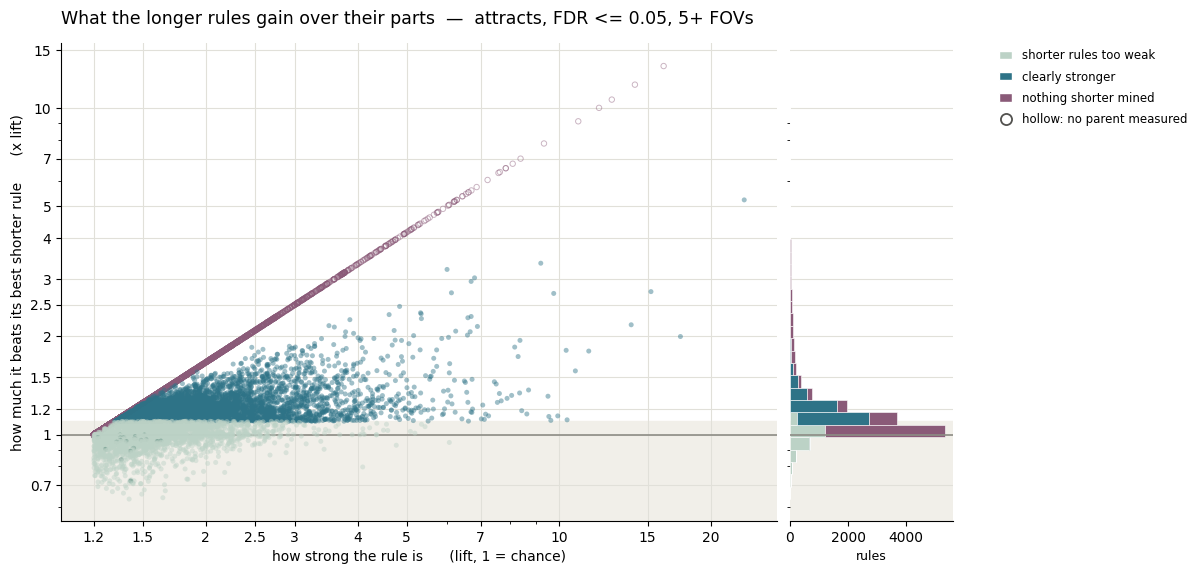

In [17]:
show_gain_scatter()

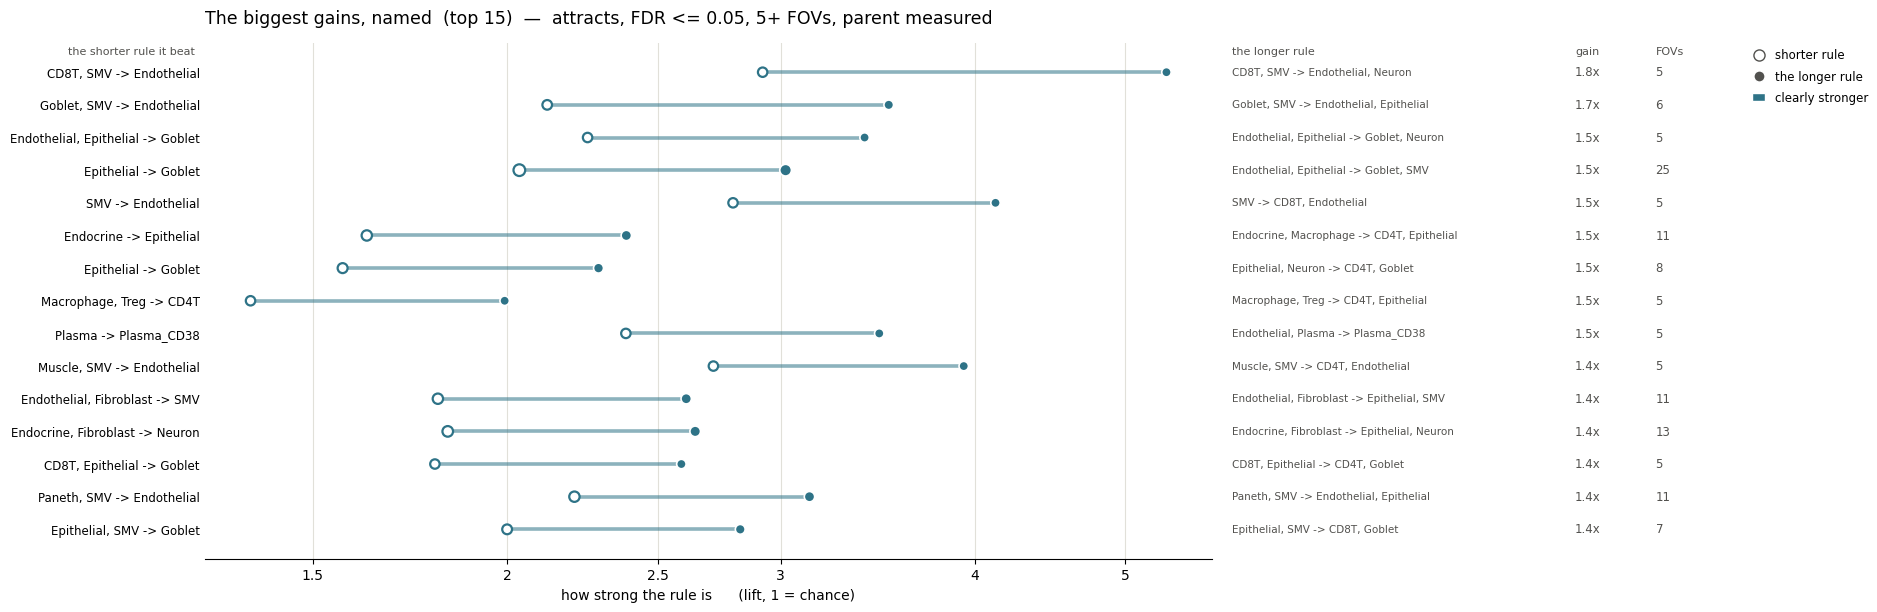

In [18]:
show_gain_dumbbell()

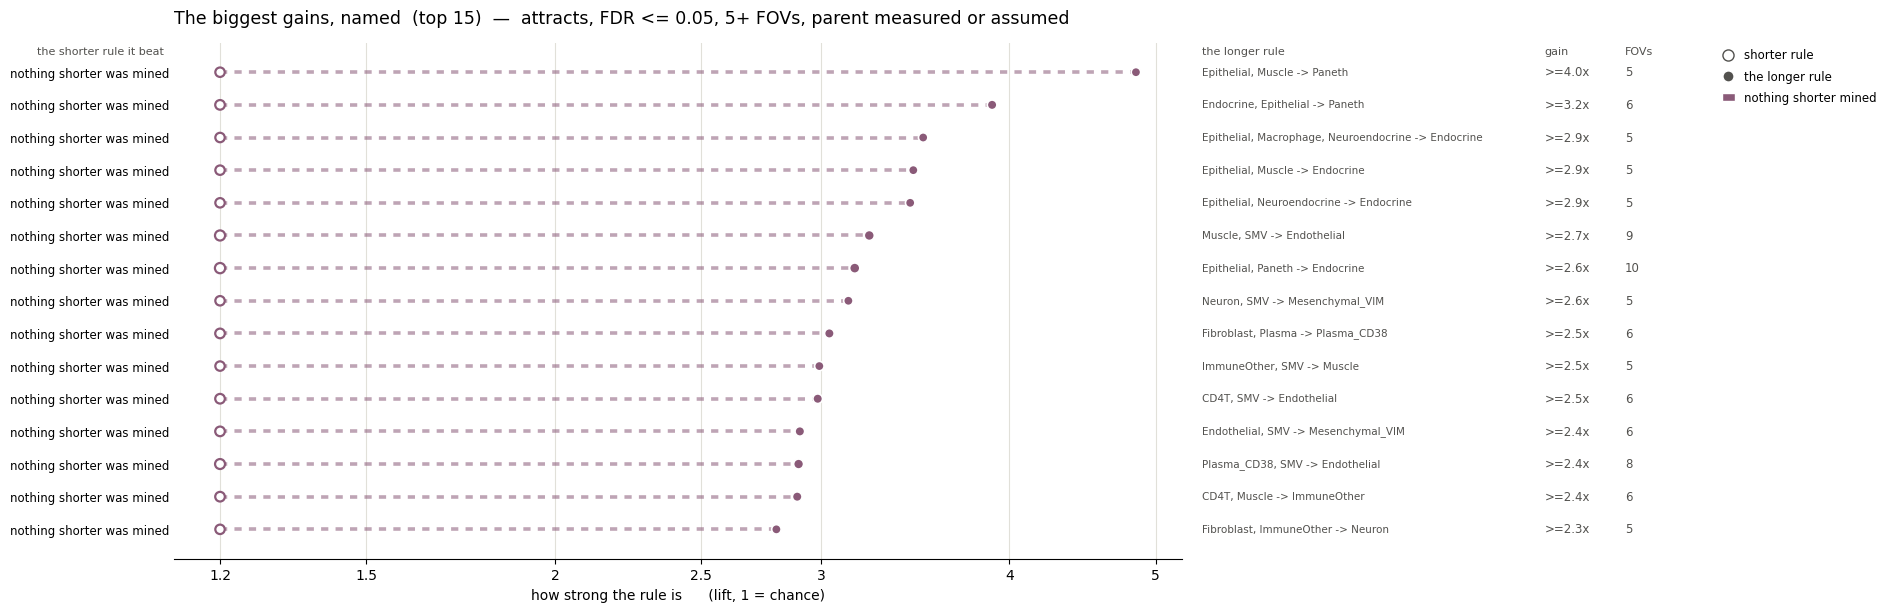

In [19]:
show_gain_dumbbell(include_new=True)

### Organ by organ

#### Colon

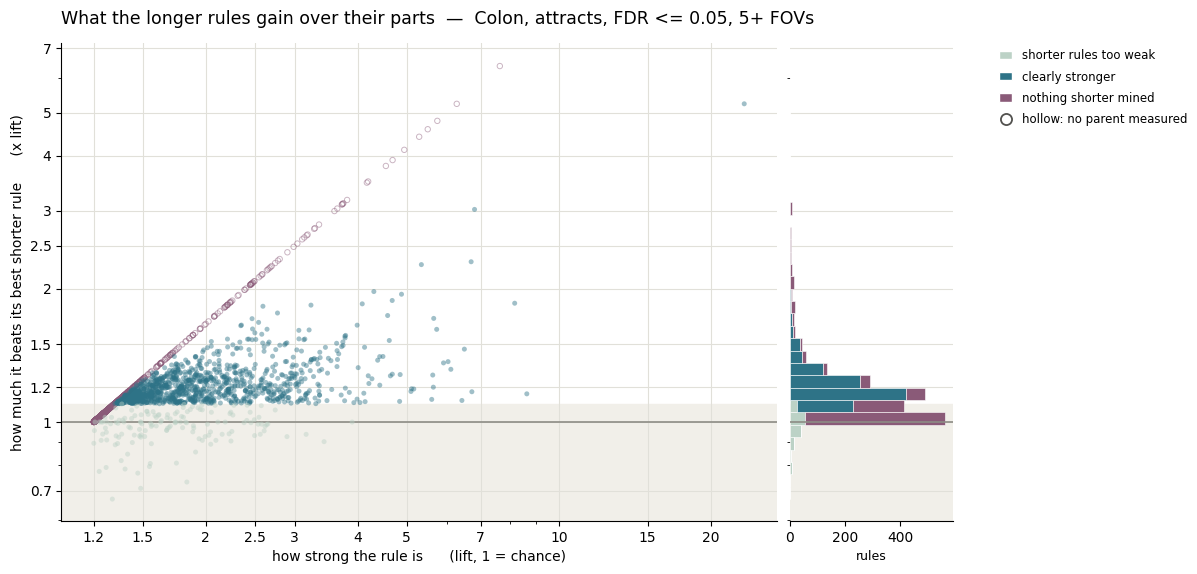

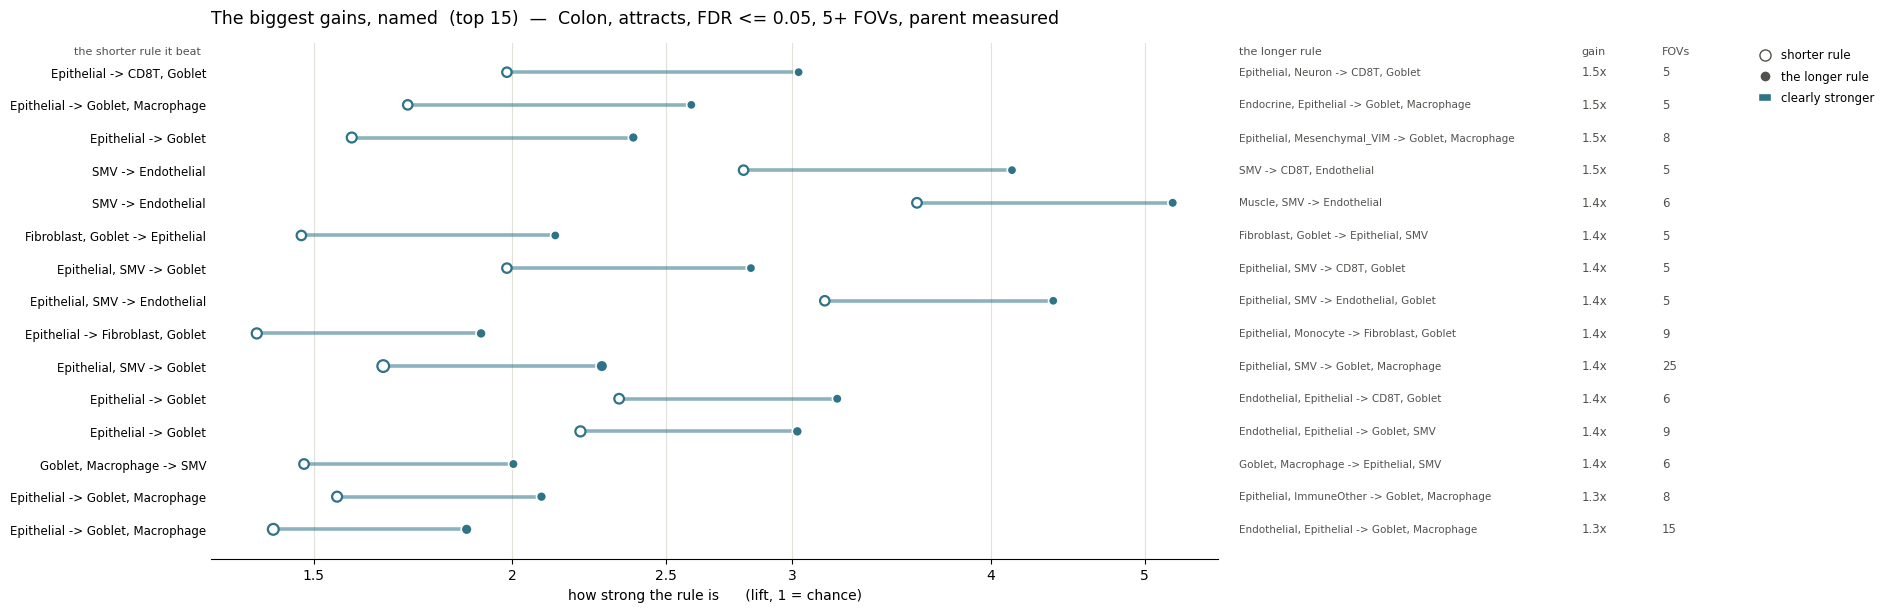

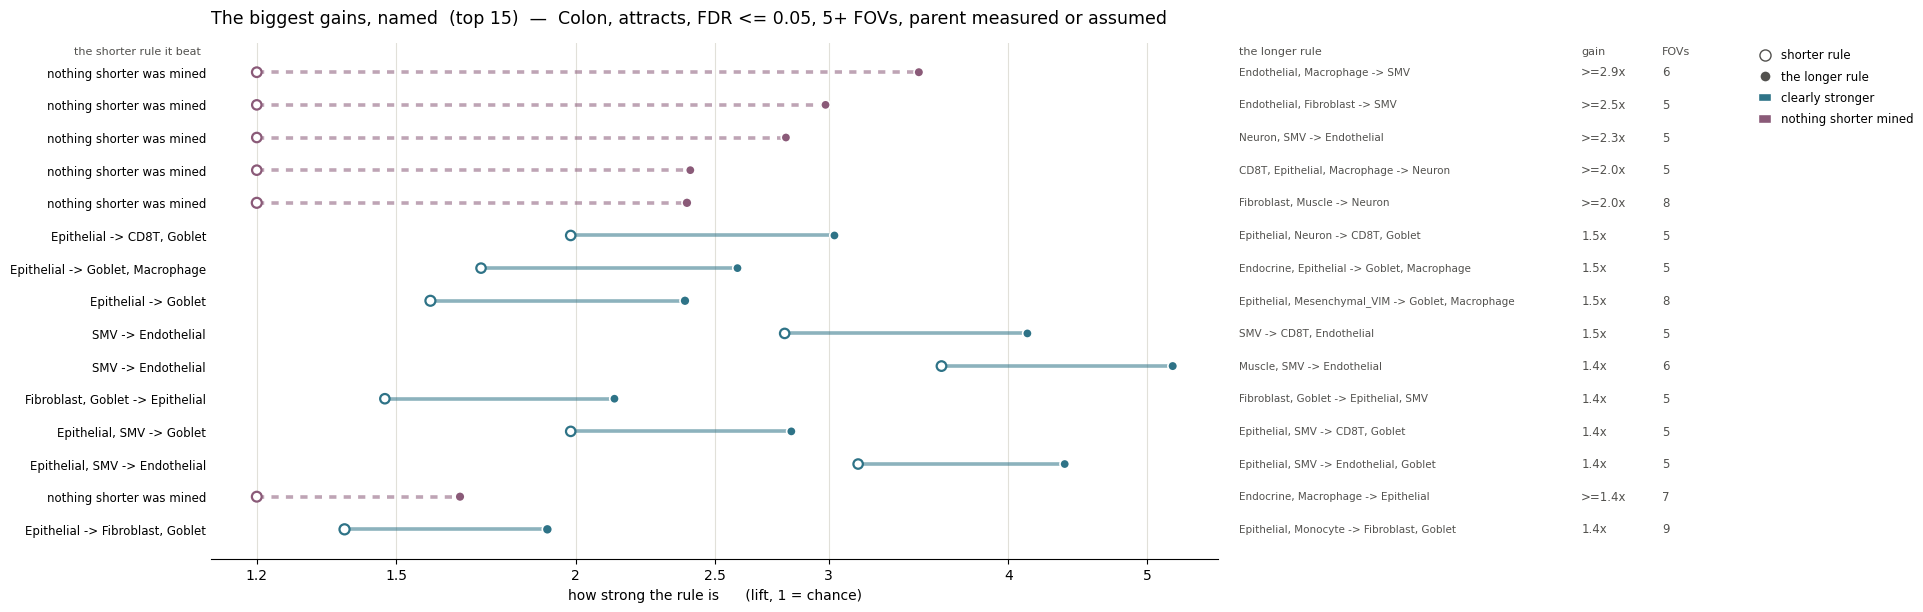

#### Duodenum

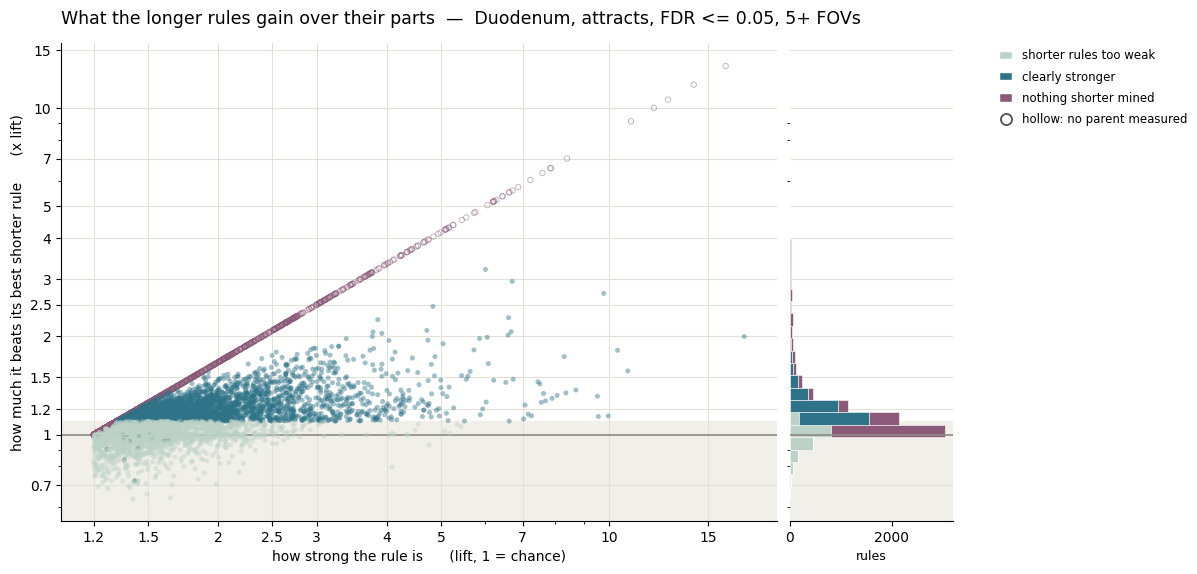

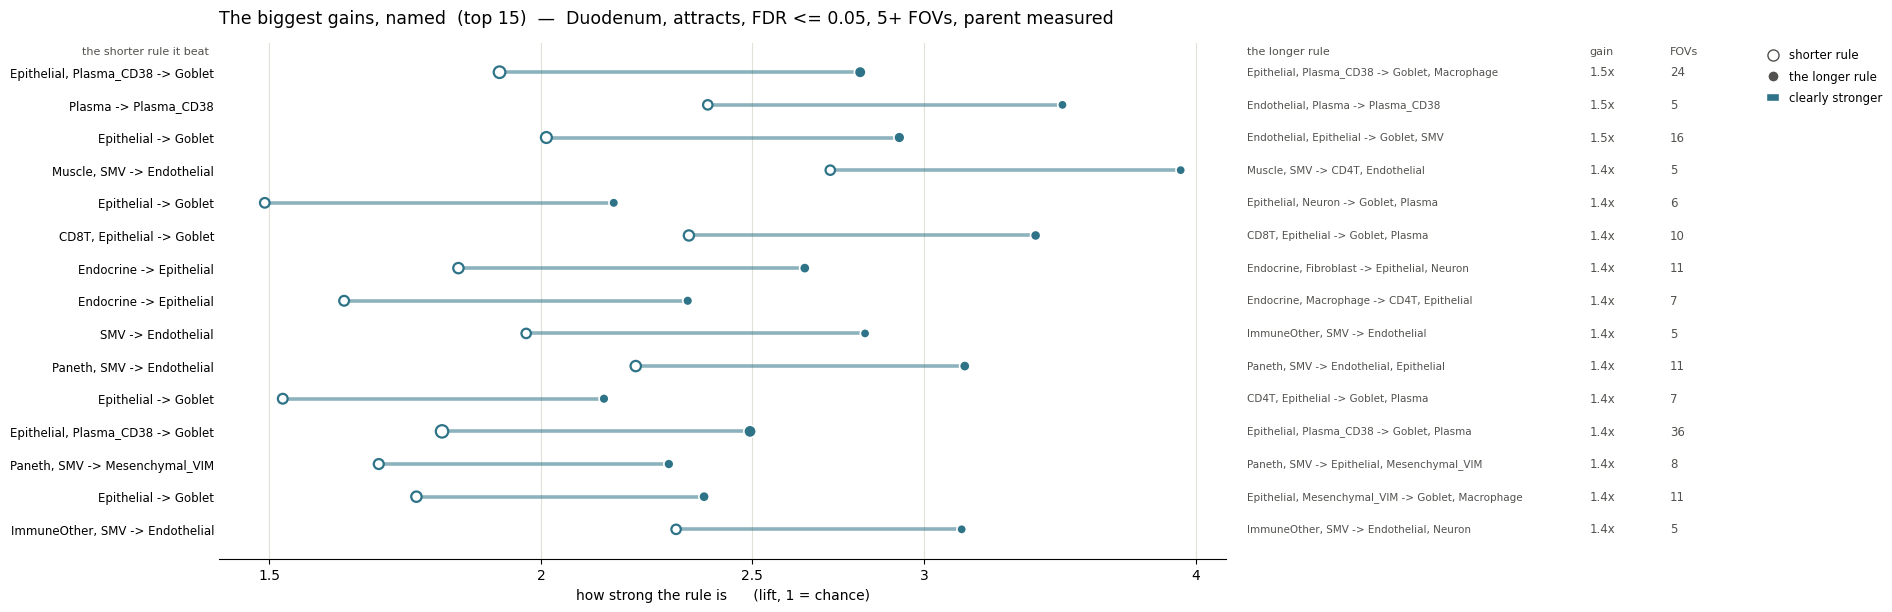

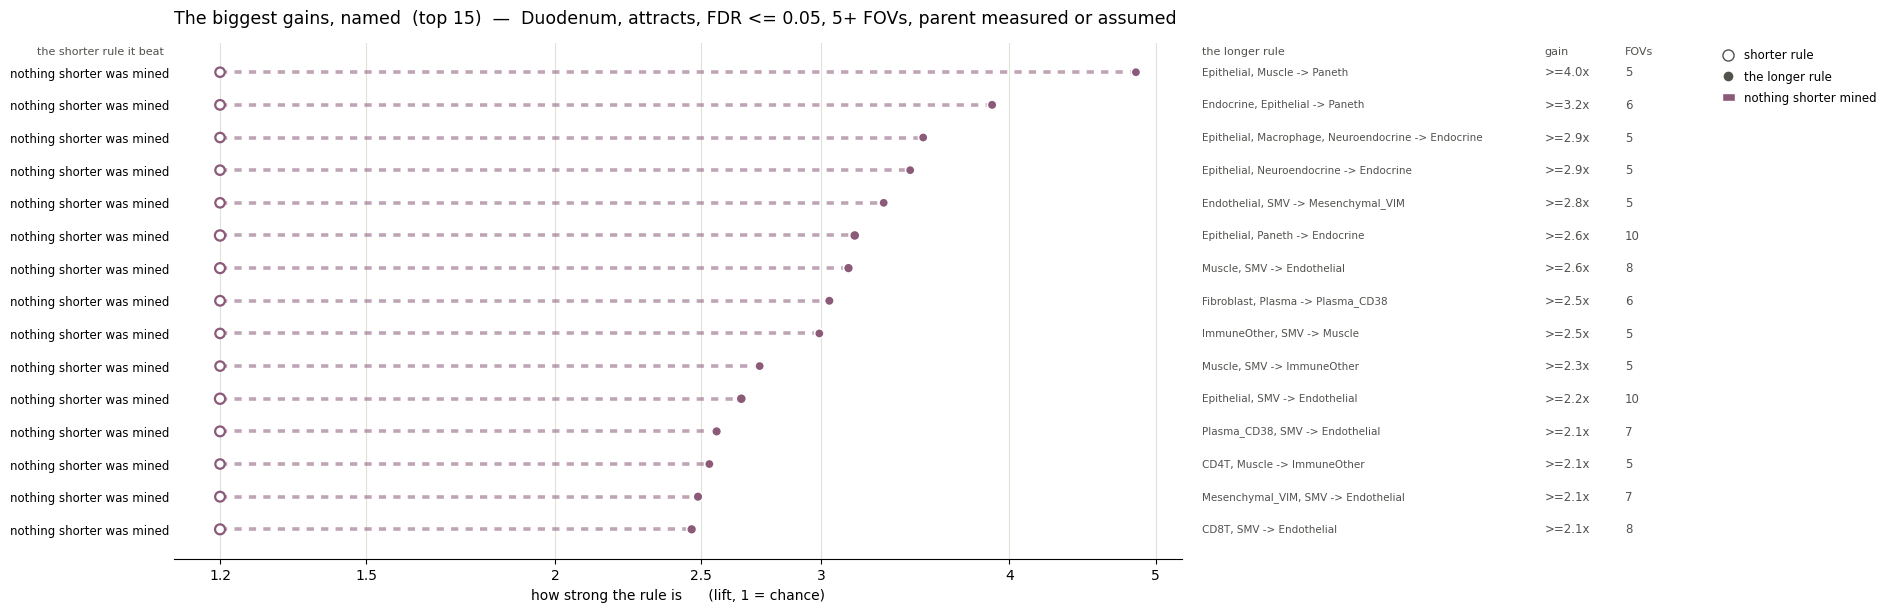

In [20]:
for organ in ORGAN_ORDER:
    display(Markdown(f'#### {organ}'))
    organ_rules = df_results[df_results['Organ'] == organ]
    table = gain_table(organ_rules)

    show_gain_scatter(gain_table(organ_rules, per='fov'), where=organ)
    show_gain_dumbbell(table, where=organ)
    show_gain_dumbbell(table, where=organ, include_new=True)